<a href="https://colab.research.google.com/github/Ch-MANASA19/ML-Customer-Churn-Project1/blob/main/02_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("Telco_customer_churn.csv")

# =========================
# 3. CLEANING
# =========================

# Drop ID
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Fill missing
df.fillna(df.median(numeric_only=True), inplace=True)

# =========================
# 4. FEATURE ENGINEERING
# =========================

# Avg Monthly Spend
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Service Count (important)
df['ServiceCount'] = (
    (df['PhoneService'] == 'Yes').astype(int) +
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int)
)

# Contract Value
df['ContractValue'] = df['MonthlyCharges'] * df['tenure']

# =========================
# 5. ENCODING
# =========================

# Label Encoding (binary)
le = LabelEncoder()
for col in df.columns:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])

# One-Hot Encoding (multi-category)
df = pd.get_dummies(df, drop_first=True)

# =========================
# 6. FEATURE & TARGET SPLIT
# =========================

X = df.drop("Churn", axis=1)
y = df["Churn"]

# =========================
# 7. FEATURE SCALING
# =========================

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)

# =========================
# FEATURE SELECTION (FINAL FIX)
# =========================

# Convert scaled data back to DataFrame
X_df = pd.DataFrame(X_std, columns=X.columns)

# Reset index (VERY IMPORTANT )
X_df = X_df.reset_index(drop=True)
y = y.reset_index(drop=True)

# Correlation with target
corr = X_df.apply(lambda col: col.corr(y))

# Select important features
selected_features = corr[abs(corr) > 0.05].index.tolist()

# Final dataset
X_selected = X_df[selected_features]

print("Number of selected features:", len(selected_features))
print("Selected Features:", selected_features[:10])

# =========================
# 9. CLASS IMBALANCE
# =========================

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_std, y)

print("After SMOTE:", np.bincount(y_res))

# =========================
# 10. TRAIN / VAL / TEST SPLIT
# =========================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_res, y_res, test_size=0.3, stratify=y_res, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)



Number of selected features: 28
Selected Features: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'ContractValue', 'InternetService_Fiber optic']
After SMOTE: [5174 5174]
Train size: (7243, 33)
Validation size: (1552, 33)
Test size: (1553, 33)


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

y = df["Churn"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X, y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X_res, y_res, test_size=0.3, stratify=y_res, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [ ]:
#---03_Classification algorithms.ipynb


Logistic
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       777
           1       0.84      0.84      0.84       776

    accuracy                           0.84      1553
   macro avg       0.84      0.84      0.84      1553
weighted avg       0.84      0.84      0.84      1553

ROC-AUC: 0.9185938515835421


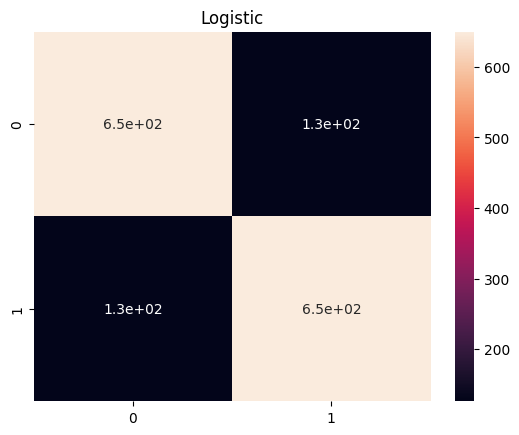


DecisionTree
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       777
           1       0.80      0.83      0.81       776

    accuracy                           0.81      1553
   macro avg       0.81      0.81      0.81      1553
weighted avg       0.81      0.81      0.81      1553

ROC-AUC: 0.8509922846263053


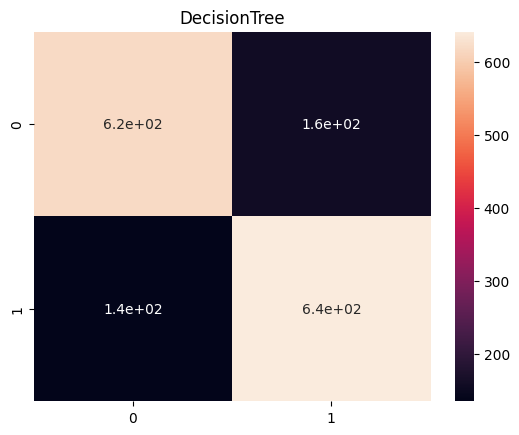


RandomForest
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       777
           1       0.84      0.87      0.86       776

    accuracy                           0.85      1553
   macro avg       0.85      0.85      0.85      1553
weighted avg       0.85      0.85      0.85      1553

ROC-AUC: 0.9313502567368546


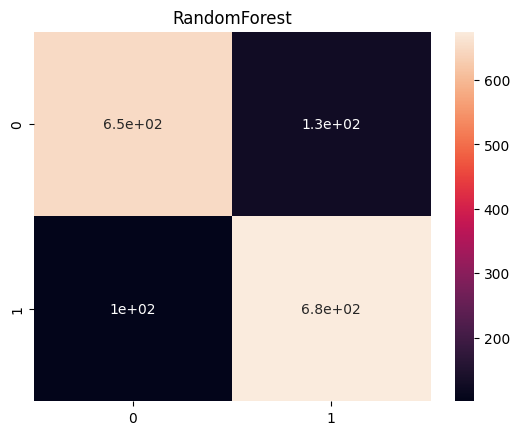


SVM
              precision    recall  f1-score   support

           0       0.75      0.66      0.71       777
           1       0.70      0.78      0.74       776

    accuracy                           0.72      1553
   macro avg       0.73      0.72      0.72      1553
weighted avg       0.73      0.72      0.72      1553

ROC-AUC: 0.8124635128501109


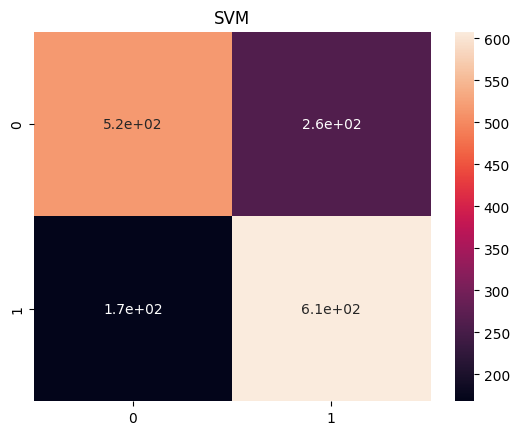


KNN
              precision    recall  f1-score   support

           0       0.83      0.71      0.77       777
           1       0.75      0.85      0.80       776

    accuracy                           0.78      1553
   macro avg       0.79      0.78      0.78      1553
weighted avg       0.79      0.78      0.78      1553

ROC-AUC: 0.8383270973477159


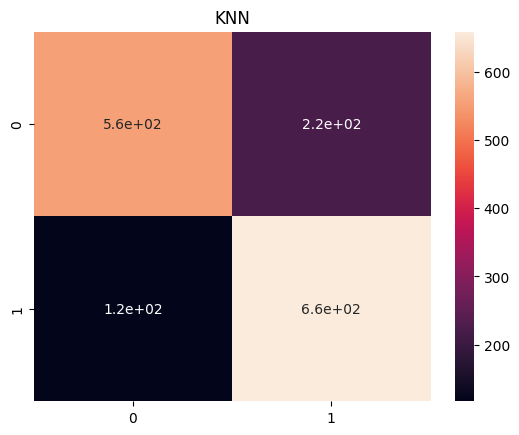

In [ ]:
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)


from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic": (LogisticRegression(max_iter=1000), {'C':[0.1,1,10]}),
    "DecisionTree": (DecisionTreeClassifier(), {'max_depth':[5,10]}),
    "RandomForest": (RandomForestClassifier(), {'n_estimators':[50,100]}),
    "SVM": (SVC(probability=True), {'C':[1,10]}),
    "KNN": (KNeighborsClassifier(), {'n_neighbors':[3,5]})
}

results = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=3)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, preds))

    roc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    print("ROC-AUC:", roc)

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True)
    plt.title(name)
    plt.show()

    results[name] = roc

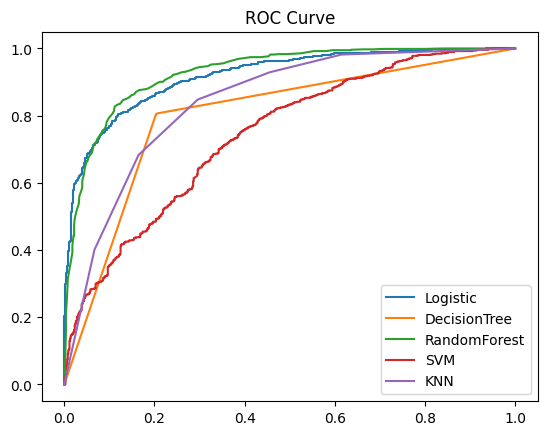

In [ ]:

import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import roc_curve

for name, (model, _) in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve")
plt.show()

In [ ]:
#04---Regression.ipynb

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_reg = df.drop("MonthlyCharges", axis=1)
y_reg = df["MonthlyCharges"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, random_state=42)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "SVR": SVR()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("R2:", r2_score(y_test, preds))


Linear
MAE: 0.7885085602107943
RMSE: 1.0497497161841918
R2: 0.9987741276614353

Ridge
MAE: 0.7885210150889995
RMSE: 1.0496767352043372
R2: 0.9987742981063578

Lasso
MAE: 4.99943598466682
RMSE: 6.217975957222778
R2: 0.9569897674690748

ElasticNet
MAE: 8.361467551211959
RMSE: 10.377015075393116
R2: 0.8802105394987682

DecisionTree
MAE: 1.7622941510505399
RMSE: 2.9022030442299407
R2: 0.9906302220193293

RandomForest
MAE: 1.1711206998188257
RMSE: 1.7871184313967492
R2: 0.9964471212906052

SVR
MAE: 19.073860311014695
RMSE: 22.81039864618718
R2: 0.42118541729313586


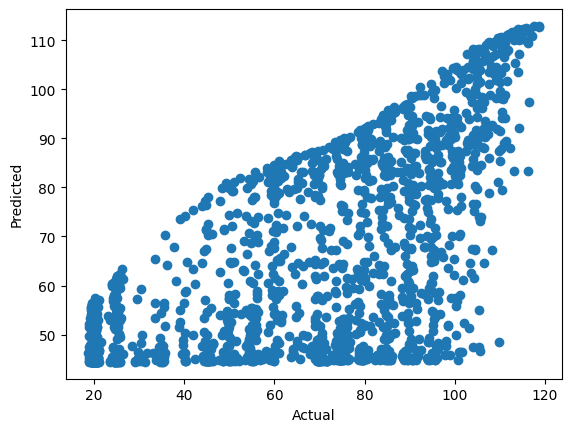

In [ ]:
plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
#05_interpretation.ipynb

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Step 1: Define X, y
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Step 2: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
import pandas as pd

df = pd.read_csv("Telco_customer_churn.csv")

# Basic preprocessing
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)

# Encoding
df = pd.get_dummies(df, drop_first=True)

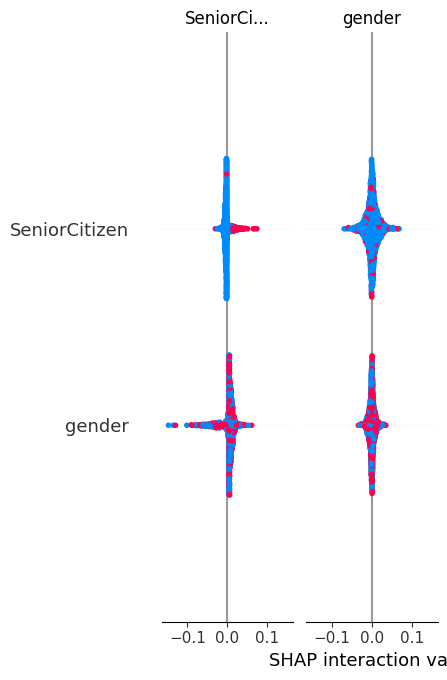

In [ ]:
import shap

# Convert to numeric (safety)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
cost = 50 * 100
saved = 500 * 60   # assume 60 retained customers

roi = saved - cost
print("ROI:", roi)

ROI: 25000


In [ ]:
import pandas as pd

results_df = pd.DataFrame(list(results.items()), columns=["Model", "ROC-AUC"])
print(results_df)

          Model   ROC-AUC
0      Logistic  0.918594
1  DecisionTree  0.850992
2  RandomForest  0.931350
3           SVM  0.812464
4           KNN  0.838327


# New Section